In [1]:
# Cell 1: Install packages and initialise the environment

!pip -q install transformers datasets accelerate evaluate sentencepiece

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import set_seed

SEED_VALUE = 2026

random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
torch.manual_seed(SEED_VALUE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_VALUE)

set_seed(SEED_VALUE)

print("Environment ready")
print("Torch Version:", torch.__version__)
print("GPU:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
Environment ready
Torch Version: 2.11.0+cu128
GPU: True


In [3]:
# Cell 2: Load the AG News dataset

ag_news = load_dataset("fancyzhx/ag_news")

print(ag_news)

# Convert to pandas
full_train = ag_news["train"].to_pandas()
full_test = ag_news["test"].to_pandas()

# Create balanced subsets
train_sample = (
    full_train
    .groupby("label", group_keys=False)
    .sample(n=2000, random_state=SEED_VALUE)
    .sample(frac=1, random_state=SEED_VALUE)
    .reset_index(drop=True)
)

test_sample = (
    full_test
    .groupby("label", group_keys=False)
    .sample(n=500, random_state=SEED_VALUE)
    .sample(frac=1, random_state=SEED_VALUE)
    .reset_index(drop=True)
)

print("Training shape:", train_sample.shape)
print("Test shape:", test_sample.shape)

display(train_sample.head())

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Training shape: (8000, 2)
Test shape: (2000, 2)


,text,label
0,Governing party leads in Romania Romania #39;s...,0
1,Poll: Kerry Continues to Hold Edge in Pa. (AP)...,0
2,Anti-Bush protest at a trade summit in Chile t...,0
3,Volatile Oil Prices Hold Stocks in Check NEW Y...,0
4,"Johnson Wins, Busch Gains in Title Chase MARTI...",1


In [4]:
# Cell 3: Inspect the sampled AG News data

topic_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

train_sample["topic"] = train_sample["label"].map(topic_names)
test_sample["topic"] = test_sample["label"].map(topic_names)

print("Training columns:")
print(train_sample.columns.tolist())

print("\nMissing values:")
print(train_sample.isnull().sum())

print("\nTraining class counts:")
print(train_sample["topic"].value_counts())

print("\nDuplicate articles:")
print(train_sample["text"].duplicated().sum())

print("\nSample articles:")
display(
    train_sample[["text", "topic"]]
    .sample(5, random_state=SEED_VALUE)
)

Training columns:
['text', 'label', 'topic']

Missing values:
text     0
label    0
topic    0
dtype: int64

Training class counts:
topic
World       2000
Sports      2000
Business    2000
Sci/Tech    2000
Name: count, dtype: int64

Duplicate articles:
0

Sample articles:


,text,topic
1151,Apple Stock Jumps to 4-Year High on IPod (AP) ...,Sci/Tech
239,Police Interview Fan Who Threw Beverage at Pac...,Sports
397,"Stern Goes Satellite, But Will Listeners Follo...",Business
1551,UAPB Gets #36;2.5M Science Grant From NSF (AP...,Sci/Tech
2299,"3 Dead, 7 Hurt in Iraq Suicide Car Blast SAMAR...",World


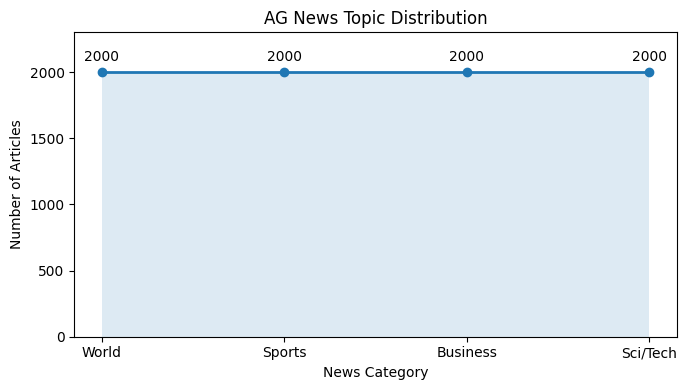

In [5]:
# Cell 4: Plot the balanced topic distribution

topic_counts = (
    train_sample["topic"]
    .value_counts()
    .reindex(["World", "Sports", "Business", "Sci/Tech"])
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    topic_counts.index,
    topic_counts.values,
    marker="o",
    linewidth=2
)

ax.fill_between(
    topic_counts.index,
    topic_counts.values,
    alpha=0.15
)

ax.set_title("AG News Topic Distribution")
ax.set_xlabel("News Category")
ax.set_ylabel("Number of Articles")
ax.set_ylim(0, 2300)

for topic, count in topic_counts.items():
    ax.annotate(
        str(count),
        (topic, count),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.tight_layout()
plt.show()

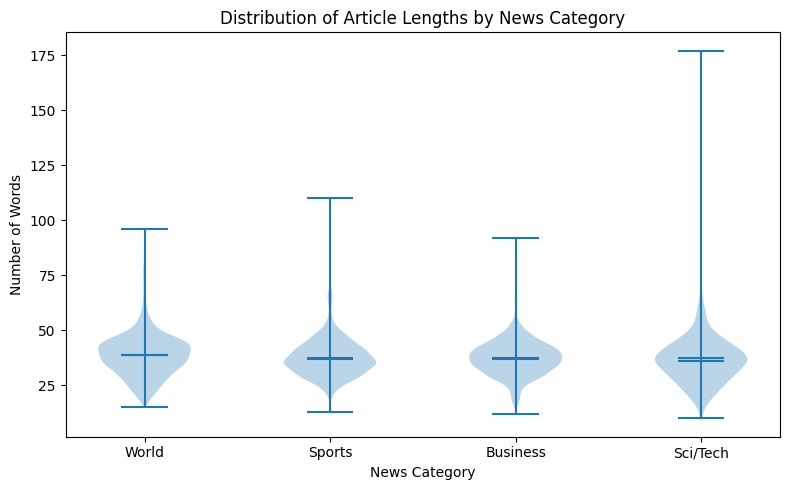

Article Length Summary


,article_length
count,8000.000000
mean,37.742625
std,10.100923
min,10.000000
25%,32.000000
50%,37.000000
75%,43.000000
max,177.000000


In [6]:
# Cell 5: Analyse article lengths by topic

# Calculate the number of words in each article
train_sample["article_length"] = train_sample["text"].str.split().str.len()

topics = ["World", "Sports", "Business", "Sci/Tech"]

length_data = [
    train_sample.loc[
        train_sample["topic"] == topic,
        "article_length"
    ]
    for topic in topics
]

plt.figure(figsize=(8, 5))

plt.violinplot(
    length_data,
    showmeans=True,
    showmedians=True
)

plt.xticks(
    range(1, len(topics) + 1),
    topics
)

plt.title("Distribution of Article Lengths by News Category")
plt.xlabel("News Category")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

print("Article Length Summary")
display(
    train_sample["article_length"].describe()
)

In [7]:
# Cell 6: Create training and validation splits

from sklearn.model_selection import train_test_split

train_df, validation_df = train_test_split(
    train_sample,
    test_size=0.20,
    stratify=train_sample["label"],
    random_state=SEED_VALUE
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_sample.reset_index(drop=True)

print("Training Set:", train_df.shape)
print("Validation Set:", validation_df.shape)
print("Test Set:", test_df.shape)

print("\nTraining Label Distribution")
print(train_df["topic"].value_counts())

print("\nValidation Label Distribution")
print(validation_df["topic"].value_counts())

Training Set: (6400, 4)
Validation Set: (1600, 4)
Test Set: (2000, 3)

Training Label Distribution
topic
World       1600
Business    1600
Sports      1600
Sci/Tech    1600
Name: count, dtype: int64

Validation Label Distribution
topic
Sports      400
World       400
Business    400
Sci/Tech    400
Name: count, dtype: int64


In [8]:
# Cell 7: Convert pandas DataFrames to Hugging Face datasets

from datasets import Dataset, DatasetDict

news_dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["text", "label"]],
        preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        validation_df[["text", "label"]],
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df[["text", "label"]],
        preserve_index=False
    )
})

print(news_dataset)

print("\nExample record:")
print(news_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Example record:
{'text': 'Clock ticks down for French hostages, Iraq government in security &lt;b&gt;...&lt;/b&gt; BAGHDAD : The clock was ticking down for two French hostages whose Islamist abductors have served Paris with an ultimatum to lift a ban on Muslim headscarves in schools, while Iraq #39;s government continued efforts to end the chaos prevailing in the country.', 'label': 0}


In [9]:
# Cell 8: Train a TF-IDF Logistic Regression classifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

news_vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=12000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_news = news_vectorizer.fit_transform(train_df["text"])
X_validation_news = news_vectorizer.transform(validation_df["text"])
X_test_news = news_vectorizer.transform(test_df["text"])

news_logistic_model = LogisticRegression(
    C=1.5,
    max_iter=1200,
    solver="liblinear",
    random_state=SEED_VALUE
)

news_logistic_model.fit(
    X_train_news,
    train_df["label"]
)

print("Logistic Regression baseline trained successfully.")
print("Training matrix shape:", X_train_news.shape)
print("Vocabulary size:", len(news_vectorizer.get_feature_names_out()))

Logistic Regression baseline trained successfully.
Training matrix shape: (6400, 12000)
Vocabulary size: 12000


In [10]:
# Cell 9: Evaluate Logistic Regression on the AG News test set

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

news_predictions = news_logistic_model.predict(X_test_news)

news_accuracy = accuracy_score(
    test_df["label"],
    news_predictions
)

news_precision, news_recall, news_f1, _ = precision_recall_fscore_support(
    test_df["label"],
    news_predictions,
    average="macro",
    zero_division=0
)

class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Logistic Regression Test Results")
print(f"Accuracy : {news_accuracy:.4f}")
print(f"Precision: {news_precision:.4f}")
print(f"Recall   : {news_recall:.4f}")
print(f"F1-score : {news_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_df["label"],
        news_predictions,
        target_names=class_names,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        test_df["label"],
        news_predictions
    )
)

Logistic Regression Test Results
Accuracy : 0.8720
Precision: 0.8720
Recall   : 0.8720
F1-score : 0.8713

Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.86      0.87       500
      Sports       0.88      0.96      0.92       500
    Business       0.87      0.82      0.85       500
    Sci/Tech       0.84      0.85      0.84       500

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix:
[[428  34  22  16]
 [ 14 481   1   4]
 [ 19  10 411  60]
 [ 20  20  36 424]]


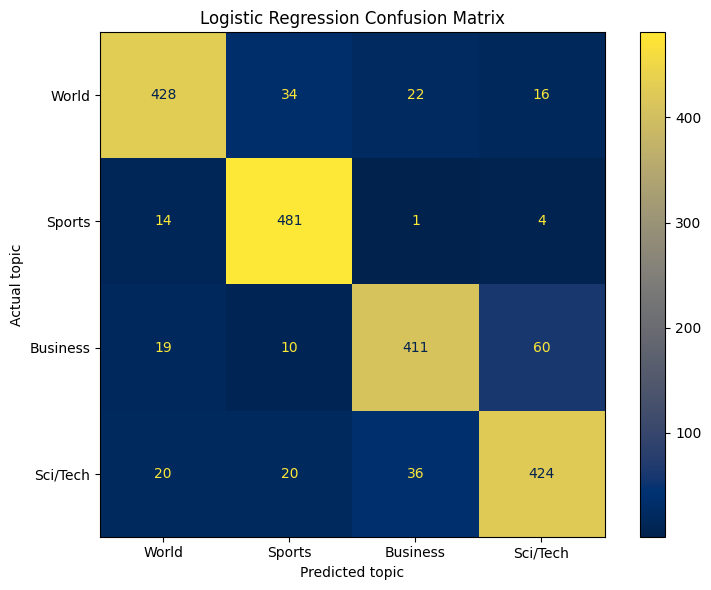

In [11]:
# Cell 10: Visualise baseline classification errors

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    news_predictions,
    display_labels=class_names,
    cmap="cividis",
    values_format="d",
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted topic")
ax.set_ylabel("Actual topic")

plt.tight_layout()
plt.show()

In [12]:
# Cell 11: Load the tokenizer for news classification

from transformers import AutoTokenizer

NEWS_MODEL = "distilbert-base-uncased"
MAX_NEWS_LENGTH = 128

news_tokenizer = AutoTokenizer.from_pretrained(NEWS_MODEL)

preview_article = train_df.loc[0, "text"]

preview_encoding = news_tokenizer(
    preview_article,
    truncation=True,
    max_length=MAX_NEWS_LENGTH
)

print("Tokenizer loaded successfully.")
print("Model:", NEWS_MODEL)
print("Maximum sequence length:", MAX_NEWS_LENGTH)

print("\nSample article:")
print(preview_article[:300])

print("\nFirst 20 token IDs:")
print(preview_encoding["input_ids"][:20])

print("\nFirst 20 attention-mask values:")
print(preview_encoding["attention_mask"][:20])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.
Model: distilbert-base-uncased
Maximum sequence length: 128

Sample article:
Clock ticks down for French hostages, Iraq government in security &lt;b&gt;...&lt;/b&gt; BAGHDAD : The clock was ticking down for two French hostages whose Islamist abductors have served Paris with an ultimatum to lift a ban on Muslim headscarves in schools, while Iraq #39;s government continued eff

First 20 token IDs:
[101, 5119, 16356, 2015, 2091, 2005, 2413, 19323, 1010, 5712, 2231, 1999, 3036, 1004, 8318, 1025, 1038, 1004, 14181, 1025]

First 20 attention-mask values:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [13]:
# Cell 12: Tokenize the AG News dataset

def tokenize_news(batch):
    return news_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_NEWS_LENGTH
    )

tokenized_news = news_dataset.map(
    tokenize_news,
    batched=True,
    remove_columns=["text"]
)

print(tokenized_news)

sample = tokenized_news["train"][0]

print("\nSample tokenized article")
print("Label:", sample["label"])
print("First 15 input IDs:", sample["input_ids"][:15])
print("First 15 attention-mask values:", sample["attention_mask"][:15])

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Sample tokenized article
Label: 0
First 15 input IDs: [101, 5119, 16356, 2015, 2091, 2005, 2413, 19323, 1010, 5712, 2231, 1999, 3036, 1004, 8318]
First 15 attention-mask values: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [14]:
# Cell 13: Load DistilBERT with a four-class classification head

from transformers import AutoModelForSequenceClassification

NUM_NEWS_CLASSES = 4

news_model = AutoModelForSequenceClassification.from_pretrained(
    NEWS_MODEL,
    num_labels=NUM_NEWS_CLASSES
)

print("DistilBERT model loaded successfully.")
print("Model:", NEWS_MODEL)
print("Number of output classes:", news_model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.
Model: distilbert-base-uncased
Number of output classes: 4


In [15]:
# Cell 14: Define evaluation metrics for AG News

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_news_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

print("Evaluation metrics ready.")

Evaluation metrics ready.


In [16]:
# Cell 15: Configure DistilBERT fine-tuning

from transformers import TrainingArguments

news_training_args = TrainingArguments(
    output_dir="./distilbert_ag_news",

    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.10,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=25,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=1,

    # Disabled to avoid the FP16 gradient error seen earlier
    fp16=False,
    bf16=False,

    report_to="none",
    seed=SEED_VALUE
)

print("Training configuration created.")
print("GPU available:", torch.cuda.is_available())

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training configuration created.
GPU available: True


In [17]:
# Cell 16: Build the Trainer with dynamic padding and early stopping

from transformers import (
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

news_data_collator = DataCollatorWithPadding(
    tokenizer=news_tokenizer
)

news_trainer = Trainer(
    model=news_model,
    args=news_training_args,
    train_dataset=tokenized_news["train"],
    eval_dataset=tokenized_news["validation"],
    data_collator=news_data_collator,
    compute_metrics=compute_news_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("DistilBERT Trainer created successfully.")
print("Training samples:", len(tokenized_news["train"]))
print("Validation samples:", len(tokenized_news["validation"]))
print("GPU available:", torch.cuda.is_available())

DistilBERT Trainer created successfully.
Training samples: 6400
Validation samples: 1600
GPU available: True


In [18]:
# Cell 17: Fine-tune DistilBERT on AG News

news_training_output = news_trainer.train()

print("Training completed successfully.")

print("\nFinal training loss:")
print(round(news_training_output.training_loss, 4))

print("\nTraining summary:")
print(news_training_output.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.368592,0.331061,0.893125,0.894643,0.893125,0.892494
2,0.232038,0.307057,0.908750,0.908848,0.908750,0.908636
3,0.114384,0.329809,0.913125,0.913357,0.913125,0.913024


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed successfully.

Final training loss:
0.2945

Training summary:
{'train_runtime': 203.2844, 'train_samples_per_second': 94.449, 'train_steps_per_second': 5.903, 'total_flos': 455439160221696.0, 'train_loss': 0.2944889083504677, 'epoch': 3.0}


In [19]:
# Cell 18: Evaluate the fine-tuned DistilBERT model

news_test_results = news_trainer.evaluate(
    eval_dataset=tokenized_news["test"]
)

print("DistilBERT Test Results")

for metric_name, metric_value in news_test_results.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
0.114384,0.288340,3,0.922000,0.922076,0.922000,0.921841


DistilBERT Test Results
eval_loss: 0.2883
eval_accuracy: 0.9220
eval_macro_precision: 0.9221
eval_macro_recall: 0.9220
eval_macro_f1: 0.9218


DistilBERT Classification Report

              precision    recall  f1-score   support

       World       0.95      0.90      0.92       500
      Sports       0.96      0.99      0.97       500
    Business       0.89      0.89      0.89       500
    Sci/Tech       0.89      0.91      0.90       500

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



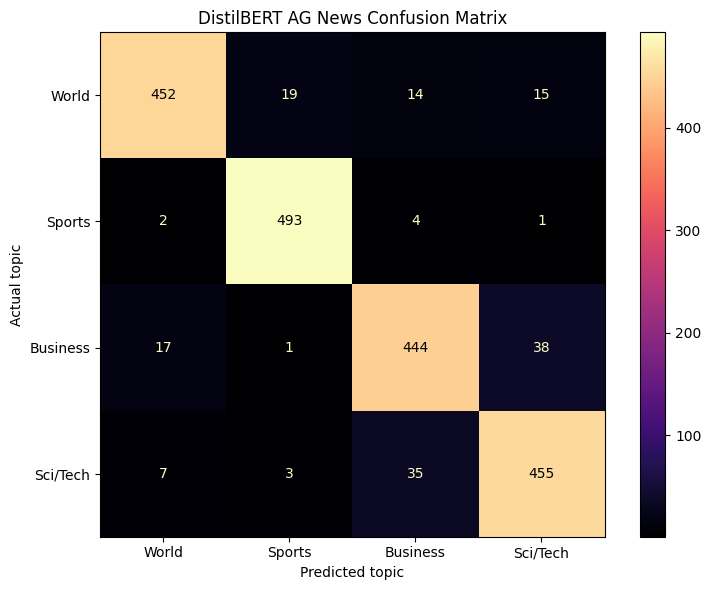

In [20]:
# Cell 19: Generate final predictions for the AG News test set

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

news_prediction_output = news_trainer.predict(
    tokenized_news["test"]
)

distilbert_predictions = np.argmax(
    news_prediction_output.predictions,
    axis=1
)

distilbert_true_labels = news_prediction_output.label_ids

print("DistilBERT Classification Report\n")

print(
    classification_report(
        distilbert_true_labels,
        distilbert_predictions,
        target_names=class_names,
        zero_division=0
    )
)

distilbert_cm = confusion_matrix(
    distilbert_true_labels,
    distilbert_predictions
)

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(
    confusion_matrix=distilbert_cm,
    display_labels=class_names
).plot(
    cmap="magma",
    values_format="d",
    ax=ax
)

ax.set_title("DistilBERT AG News Confusion Matrix")
ax.set_xlabel("Predicted topic")
ax.set_ylabel("Actual topic")

plt.tight_layout()
plt.show()